In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [3]:
csv_path = r'C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\ensia_gps_data .csv'
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} submissions.")
df[['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].head()

Loaded 8701 submissions.


,amphitheatre,latitude_mean,longitude_mean,is_outside
0,Amphi 3,36.687824,2.867150,False
1,lab 8,36.688127,2.867512,True
2,School entry,36.688729,2.865596,True
3,Amphi 4,36.688630,2.866750,False
4,room,36.688630,2.866750,True


In [4]:
df = df[['id','amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8701 entries, 0 to 8700
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              8701 non-null   int64  
 1   amphitheatre    8701 non-null   object 
 2   latitude_mean   8701 non-null   float64
 3   longitude_mean  8701 non-null   float64
 4   is_outside      8701 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(1)
memory usage: 280.5+ KB


keep only classes that hass more than 100 examples 

In [6]:
# Standardize amphitheatretheater labels
# Keep amphitheatre 1-8, change everything else to "Outside"
valid_amphis = [f"Amphi {i}" for i in range(1, 9)]  # Amphi 1 through Amphi 8

print("Before standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Replace non-standard labels with "Outside"
df['amphitheatre'] = df['amphitheatre'].apply(lambda x: x if x in valid_amphis else "Outside")

print("\nAfter standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Verify we have the expected classes
expected_classes = valid_amphis + ["Outside"]
actual_classes = sorted(df['amphitheatre'].unique())
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")
print(f"Classes match: {set(expected_classes) == set(actual_classes)}")

Before standardization:
Unique amphitheater labels: ['Amphi 3' 'lab 8' 'School entry' 'Amphi 4' 'room' 'end tarek' 'nasro '
 'mazalni end tarek' 'dorm' 'outside' 'Amphi 5' 'Amphi 1' 'Outside'
 'Amphi 7' 'Amphi 2' 'Hfgnffn' 'Amphi 6' 'Nasro' 'Mdpres end tarek'
 'SkillnTell Spot ' 'Spot ' 'Amphi 8' 'maalma3' "Salle d'études"
 'Salle d’études' 'Amphi 3 door 2 ' 'Amphi 3 door 1 ' 'AMPHI8' 'Hall'
 'tuto23' 'Dorms' 'Lab 8' 'study room' 'In front of amphi 8' 'Lab 7 '
 'lkhadra']
Label counts:
amphitheatre
Amphi 2                2565
Amphi 5                1359
Amphi 8                 989
Amphi 6                 936
Amphi 4                 741
Outside                 658
Amphi 1                 625
Amphi 3                 318
Amphi 7                 122
Nasro                   100
Mdpres end tarek         46
maalma3                  33
Dorms                    21
SkillnTell Spot          20
Salle d'études           20
Hall                     10
AMPHI8                   10
nasro               

In [7]:
counts = df['amphitheatre'].value_counts()

valid_classes = counts[counts > 100].index

df = df[df['amphitheatre'].isin(valid_classes)]

In [8]:
df['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2565
Amphi 5    1359
Outside    1046
Amphi 8     989
Amphi 6     936
Amphi 4     741
Amphi 1     625
Amphi 3     318
Amphi 7     122
Name: count, dtype: int64

In [9]:
df_a2 = df[df['amphitheatre'] == 'Amphi 2'].copy()

In [10]:
X = df_a2[['latitude_mean', 'longitude_mean']].values

In [11]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.00025,   # ~20–30 meters (adjust if needed)
    min_samples=15 # core density threshold
)

df_a2['cluster'] = db.fit_predict(X)

In [12]:
df_a2['cluster'].value_counts()

cluster
 0    2417
 1      60
-1      25
 3      24
 4      22
 2      17
Name: count, dtype: int64

In [13]:
# find largest cluster (excluding noise -1)
valid_clusters = df_a2[df_a2['cluster'] != -1]['cluster']

main_cluster = valid_clusters.value_counts().idxmax()

df_a2_clean = df_a2[df_a2['cluster'] == main_cluster].copy()
df_a2_outliers = df_a2[df_a2['cluster'] != main_cluster].copy()

In [14]:
amphi_corners = {
    "Amphi 1/5": [
        (36.6882320, 2.8666535),  # top-left
        (36.6882443, 2.8668060),  # top-right
        (36.6880865, 2.8668389),  # bottom-right
        (36.6880720, 2.8666538),  # bottom-left
    ],
    "Amphi 2/6": [
        (36.6882129, 2.8663997),  # top-left
        (36.6882193, 2.8665428),  # top-right
        (36.6880268, 2.8665894),  # bottom-right
        (36.6880123, 2.8663926),  # bottom-left
    ],
    "Amphi 3/7": [
        (36.6881935, 2.8661324),  # top-left
        (36.6881954, 2.8662759),  # top-right
        (36.6880368, 2.8663122),  # bottom-right
        (36.6880252, 2.8661318),  # bottom-left
    ],
    "Amphi 4/8": [
        (36.6881693, 2.8658652),  # top-left
        (36.6881817, 2.8660131),  # top-right
        (36.6880179, 2.8660490),  # bottom-right
        (36.6880075, 2.8658649),  # bottom-left
    ],
}

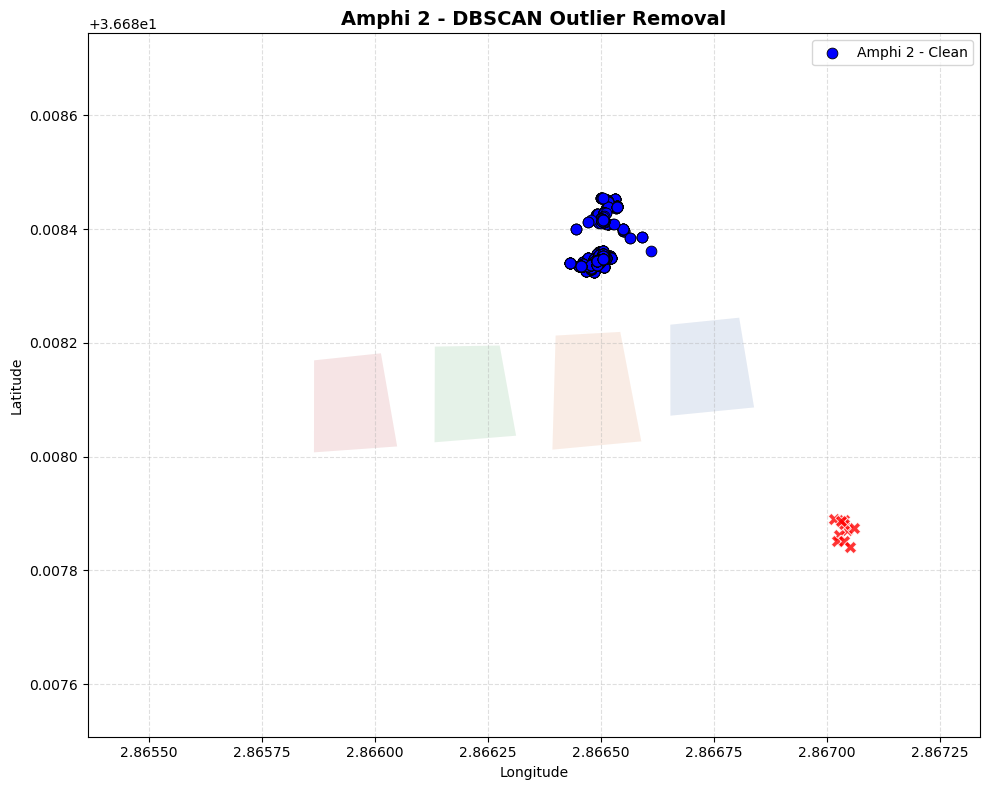

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

df_plot_out = df_a2_outliers.copy()

df_plot_out['latitude_mean'] += np.random.normal(0, 0.00002, len(df_plot_out))
df_plot_out['longitude_mean'] += np.random.normal(0, 0.00002, len(df_plot_out))

fig, ax = plt.subplots(figsize=(10, 8))

# ======================
# polygons
# ======================
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# ======================
# clean points
# ======================
sns.scatterplot(
    data=df_a2_clean,
    x='longitude_mean',
    y='latitude_mean',
    color='blue',
    label='Amphi 2 - Clean',
    s=60,
    edgecolor='black',
    ax=ax,
    zorder=3
)

# ======================
# outliers
# ======================
sns.scatterplot(
    data=df_plot_out,
    x='longitude_mean',
    y='latitude_mean',
    color='red',
    marker='X',
    s=80,
    alpha=0.8,
    ax=ax,
    zorder=6
)

# ======================
# formatting
# ======================
ax.set_title("Amphi 2 - DBSCAN Outlier Removal", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.4)
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]

ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print(df_a2_clean.shape)
print(df_a2_outliers.shape)

(2417, 6)
(148, 6)


In [17]:
df_a2_clean = df_a2[df_a2['cluster'] == 0].copy()
df_a2_noise = df_a2[df_a2['cluster'] != 0].copy()

In [18]:
print(df_a2_clean['cluster'].value_counts())

cluster
0    2417
Name: count, dtype: int64


In [19]:

clusters = sorted(df_a2_clean['cluster'].unique())

for cl in sorted(df_a2_clean['cluster'].unique()):
    print(cl, df_a2_clean[df_a2_clean['cluster'] == cl].shape)


0 (2417, 6)


Cluster 0 -> (2417, 6)


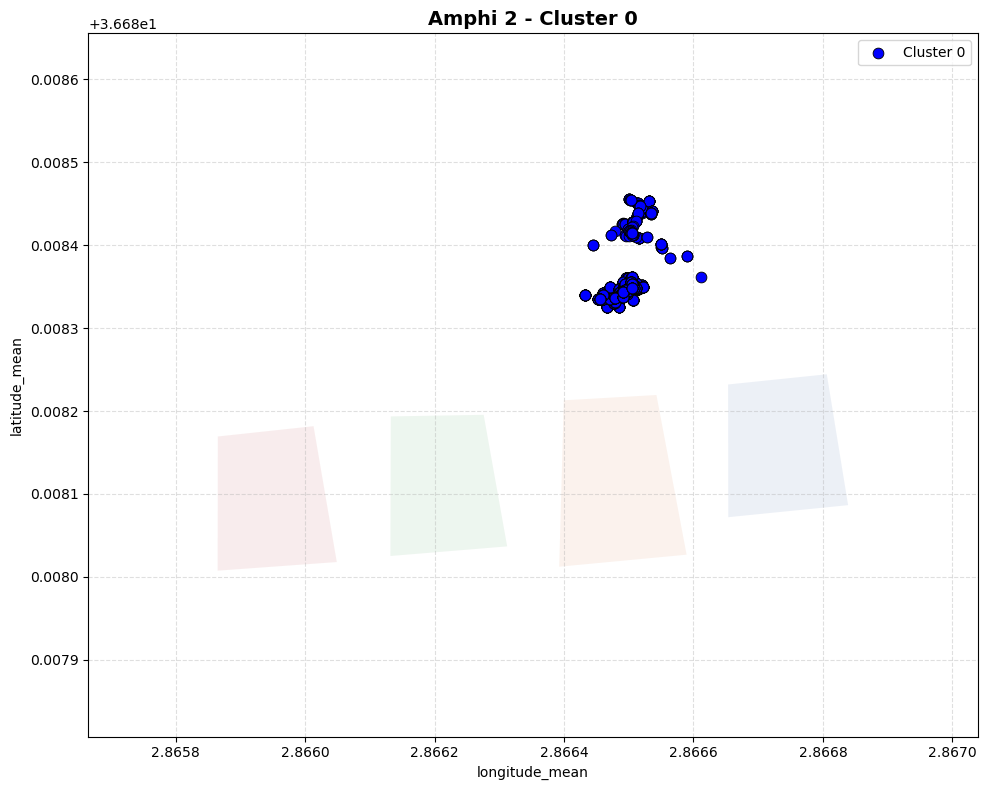

In [20]:

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Keep only valid numeric points before plotting
df_a2_clean = df_a2_clean.copy()
df_a2_clean['cluster'] = pd.to_numeric(df_a2_clean['cluster'], errors='coerce')
df_a2_clean['longitude_mean'] = pd.to_numeric(df_a2_clean['longitude_mean'], errors='coerce')
df_a2_clean['latitude_mean'] = pd.to_numeric(df_a2_clean['latitude_mean'], errors='coerce')
df_a2_clean = df_a2_clean.dropna(subset=['cluster', 'longitude_mean', 'latitude_mean'])
df_a2_clean['cluster'] = df_a2_clean['cluster'].astype(int)

clusters = sorted(df_a2_clean['cluster'].unique())

for cl in clusters:
    subset = df_a2_clean[df_a2_clean['cluster'] == cl].copy()

    print(f"Cluster {cl} -> {subset.shape}")  # DEBUG

    fig, ax = plt.subplots(figsize=(10, 8))

    # ======================
    # polygons
    # ======================
    patches = []
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for (name, corners), color in zip(amphi_corners.items(), colors):
        xy = np.array([(lon, lat) for lat, lon in corners])
        poly = Polygon(xy, closed=True)
        patches.append(poly)

    ax.add_collection(
        PatchCollection(patches, facecolors=colors, alpha=0.10, zorder=0)
    )

    # ======================
    # scatter
    # ======================
    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color='blue',
        s=60,
        edgecolor='black',
        ax=ax,
        label=f'Cluster {cl}',
        zorder=3
    )

    # ======================
    # AXIS (include polygons + cluster points)
    # ======================
    poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
    poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]

    data_lats = subset['latitude_mean'].to_list()
    data_lons = subset['longitude_mean'].to_list()

    all_lats = poly_lats + data_lats
    all_lons = poly_lons + data_lons

    lat_pad = 0.0002
    lon_pad = 0.0002
    ax.set_xlim(min(all_lons) - lon_pad, max(all_lons) + lon_pad)
    ax.set_ylim(min(all_lats) - lat_pad, max(all_lats) + lat_pad)

    ax.set_title(f"Amphi 2 - Cluster {cl}", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

In [21]:
# Keep only cluster 1 instances
df_a2_clean = df_a2[df_a2['cluster'] == 0].copy()
# Optional: keep all non-cluster-1 points (including noise) for comparison
df_a2_noise = df_a2[df_a2['cluster'] != 0].copy()

In [22]:
df_a2_clean.columns

Index(['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside',
       'cluster'],
      dtype='object')

In [23]:
df_a2_clean['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2417
Name: count, dtype: int64

# outside outlier detection and removing 

In [24]:
# Build a dataframe with only outside examples
outside_mask = (
    df['is_outside']
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(['true', '1', 'yes'])
)

df_outside = df.loc[outside_mask, ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

df_outside['latitude_mean'] = pd.to_numeric(df_outside['latitude_mean'], errors='coerce')
df_outside['longitude_mean'] = pd.to_numeric(df_outside['longitude_mean'], errors='coerce')
df_outside = df_outside.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Outside examples: {len(df_outside)}")
df_outside.head()

Outside examples: 1046


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
1,3,Outside,36.688127,2.867512,True
2,4,Outside,36.688729,2.865596,True
4,6,Outside,36.688630,2.866750,True
5,7,Outside,36.725914,2.999500,True
6,122,Outside,36.685800,2.865860,True


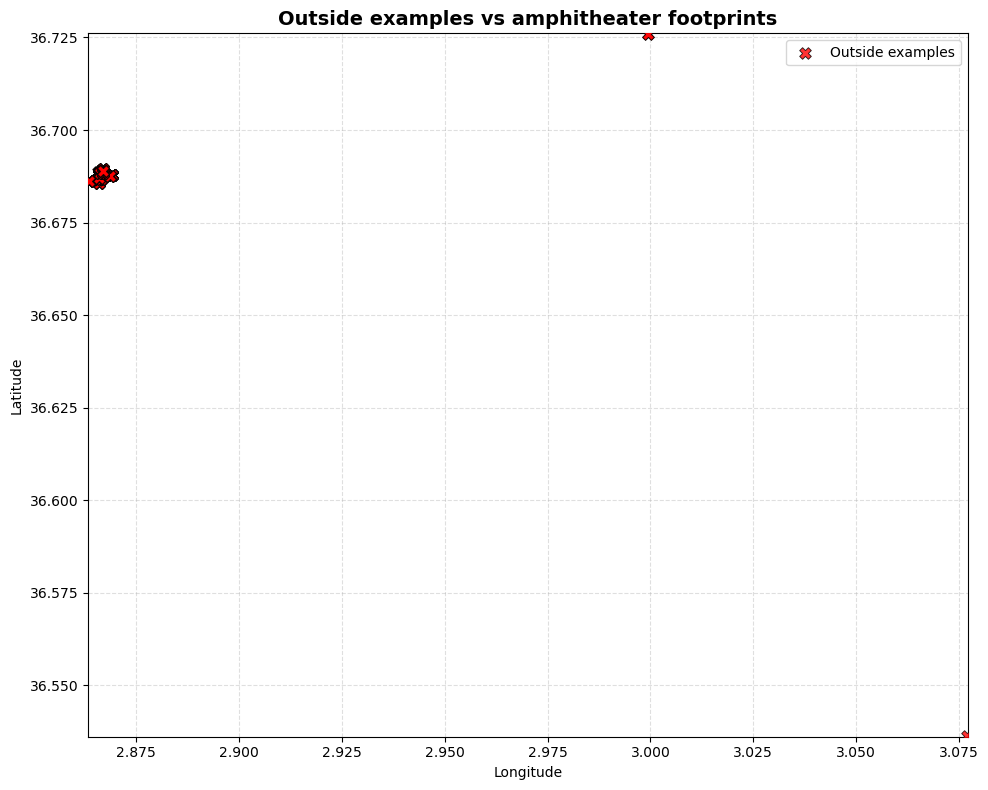

In [25]:
# Plot outside examples against amphitheater polygons
fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

sns.scatterplot(
    data=df_outside,
    x='longitude_mean',
    y='latitude_mean',
    color='red',
    marker='X',
    s=70,
    alpha=0.8,
    edgecolor='black',
    ax=ax,
    zorder=5,
    label='Outside examples'
)

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
all_lats = poly_lats + df_outside['latitude_mean'].tolist()
all_lons = poly_lons + df_outside['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

ax.set_title('Outside examples vs amphitheater footprints', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

cluster
-1      14
 0      10
 1      15
 2      10
 3      55
 4      10
 5     146
 6      10
 7     600
 8       9
 9      21
 10     23
 11     30
 12     33
 13      9
 14     10
 15     21
 16     10
 17     10
Name: count, dtype: int64


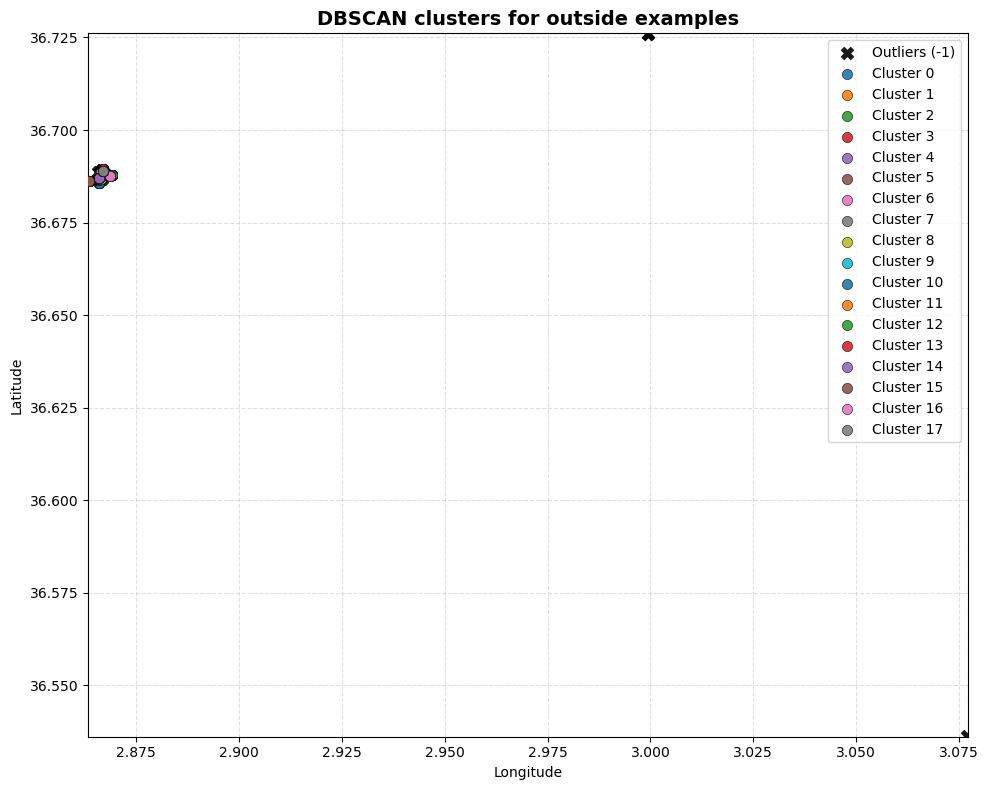

In [26]:
# Cluster outside examples with DBSCAN and plot each cluster with a different color
from sklearn.cluster import DBSCAN

X_outside = df_outside[['latitude_mean', 'longitude_mean']].values

# Tune eps/min_samples if needed for your density scale
db_out = DBSCAN(eps=0.00008, min_samples=8)
df_outside['cluster'] = db_out.fit_predict(X_outside)

print(df_outside['cluster'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.12, zorder=1))

clusters = sorted(df_outside['cluster'].unique())
palette = sns.color_palette('tab10', n_colors=max(1, len([c for c in clusters if c != -1])))
color_map = {}
color_idx = 0
for c in clusters:
    if c == -1:
        color_map[c] = 'black'  # outliers
    else:
        color_map[c] = palette[color_idx]
        color_idx += 1

for c in clusters:
    subset = df_outside[df_outside['cluster'] == c]
    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color=color_map[c],
        marker='X' if c == -1 else 'o',
        s=85 if c == -1 else 55,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        zorder=6,
        label='Outliers (-1)' if c == -1 else f'Cluster {c}'
    )

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
all_lats = poly_lats + df_outside['latitude_mean'].tolist()
all_lons = poly_lons + df_outside['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

ax.set_title('DBSCAN clusters for outside examples', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

In [27]:
df_outside['cluster'].value_counts()

cluster
 7     600
 5     146
 3      55
 12     33
 11     30
 10     23
 15     21
 9      21
 1      15
-1      14
 0      10
 16     10
 6      10
 2      10
 4      10
 17     10
 14     10
 8       9
 13      9
Name: count, dtype: int64

cluster
-1      14
 0      10
 1      15
 2      10
 3      55
 4      10
 5     146
 6      10
 7     600
 8       9
 9      21
 10     23
 11     30
 12     33
 13      9
 14     10
 15     21
 16     10
 17     10
Name: count, dtype: int64


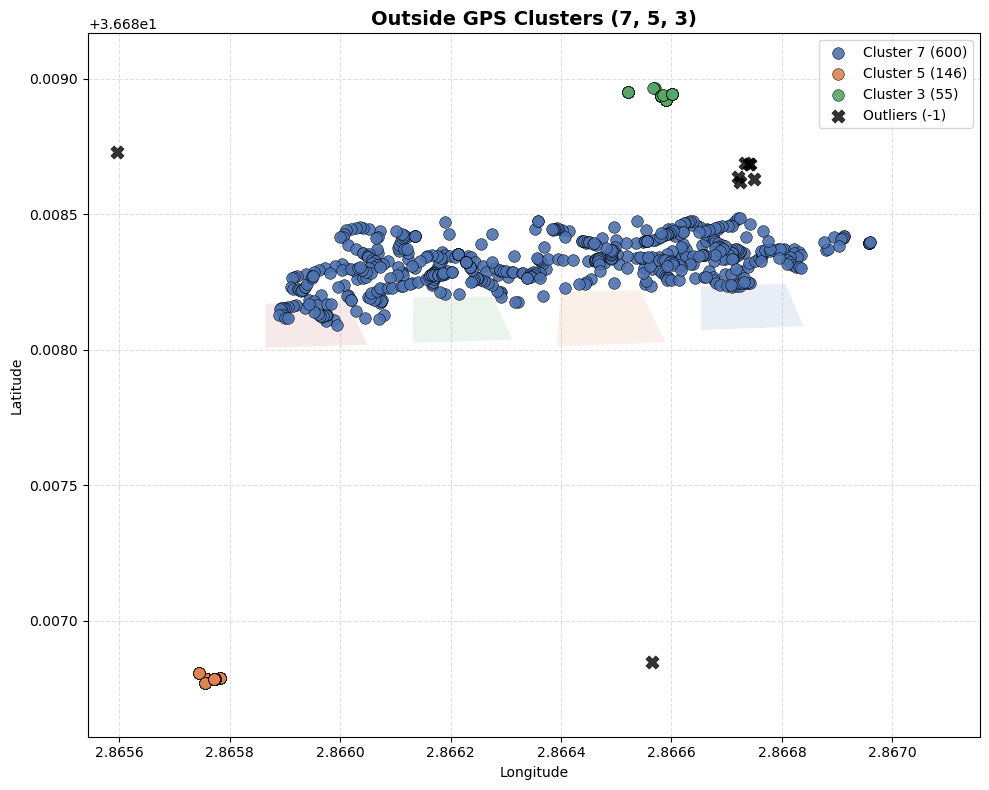

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# ── Use existing clusters (NO DBSCAN) ─────────────────────────────
X_outside = df_outside[['latitude_mean', 'longitude_mean']].values

print(df_outside['cluster'].value_counts().sort_index())

# ── Focus only on requested clusters ──────────────────────────────
target_clusters = [7, 5, 3]

df_plot = df_outside[df_outside['cluster'].isin(target_clusters)].copy()

# ── Color mapping (fixed & meaningful) ────────────────────────────
color_map = {
    7: "#4C72B0",  # blue (dominant cluster)
    5: "#DD8452",  # orange
    3: "#55A868",  # green
}

# ── Plot setup ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Amphitheatre polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.12, zorder=1))

# ── Scatter clusters ──────────────────────────────────────────────
for c in target_clusters:
    subset = df_plot[df_plot['cluster'] == c]

    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color=color_map[c],
        s=70,
        alpha=0.9,
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        zorder=6,
        label=f'Cluster {c} ({len(subset)})'
    )

# ── Outliers (optional) ───────────────────────────────────────────
outliers = df_outside[df_outside['cluster'] == -1]

if len(outliers) > 0:
    sns.scatterplot(
        data=outliers,
        x='longitude_mean',
        y='latitude_mean',
        color='black',
        marker='X',
        s=90,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.5,
        ax=ax,
        zorder=7,
        label='Outliers (-1)'
    )

# ── Bounds ────────────────────────────────────────────────────────
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]

all_lats = poly_lats + df_plot['latitude_mean'].tolist()
all_lons = poly_lons + df_plot['longitude_mean'].tolist()

ax.set_xlim(min(all_lons) - 0.0002, max(all_lons) + 0.0002)
ax.set_ylim(min(all_lats) - 0.0002, max(all_lats) + 0.0002)

# ── Final styling ──────────────────────────────────────────────────
ax.set_title('Outside GPS Clusters (7, 5, 3)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

In [101]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 7

df_outside_clean = df_outside[df_outside['cluster'] == SELECTED_CLUSTER].copy()
df_outside_noise = df_outside[df_outside['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_outside_clean)}")
print(f"Noise/outliers removed: {len(df_outside_noise)}")


Clean points kept: 600
Noise/outliers removed: 446


# amphi 5 

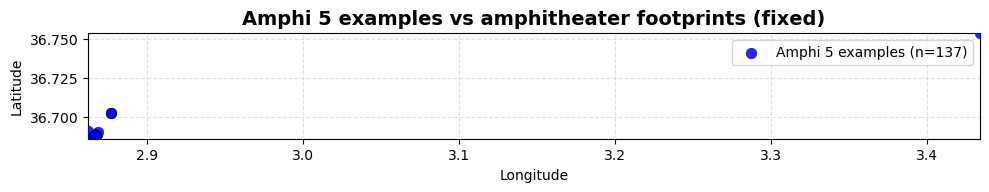

In [39]:
# Fixed plot for Amphi 5 examples against amphitheater polygons
df_a5_plot = df_a5.copy()
df_a5_plot['latitude_mean'] = pd.to_numeric(df_a5_plot['latitude_mean'], errors='coerce')
df_a5_plot['longitude_mean'] = pd.to_numeric(df_a5_plot['longitude_mean'], errors='coerce')
df_a5_plot = df_a5_plot.dropna(subset=['latitude_mean', 'longitude_mean'])

fig, ax = plt.subplots(figsize=(10, 8))

patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))

ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

sns.scatterplot(
    data=df_a5_plot,
    x='longitude_mean',
    y='latitude_mean',
    color='blue',
    marker='o',
    s=60,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
    zorder=5,
    label=f'Amphi 5 examples (n={len(df_a5_plot)})'
)

poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]

if len(df_a5_plot) > 0:
    all_lats = poly_lats + df_a5_plot['latitude_mean'].to_list()
    all_lons = poly_lons + df_a5_plot['longitude_mean'].to_list()
else:
    all_lats = poly_lats
    all_lons = poly_lons

lat_pad = 0.0002
lon_pad = 0.0002
ax.set_xlim(min(all_lons) - lon_pad, max(all_lons) + lon_pad)
ax.set_ylim(min(all_lats) - lat_pad, max(all_lats) + lat_pad)
ax.set_aspect('equal', adjustable='box')

ax.set_title('Amphi 5 examples vs amphitheater footprints (fixed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

# amphi 3 

In [34]:
# Build dataframe for Amphi 3 examples
df_a3 = df.loc[df['amphitheatre'] == 'Amphi 3', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a3['latitude_mean'] = pd.to_numeric(df_a3['latitude_mean'], errors='coerce')
df_a3['longitude_mean'] = pd.to_numeric(df_a3['longitude_mean'], errors='coerce')
df_a3 = df_a3.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 3 examples: {len(df_a3)}")
df_a3.head()


Amphi 3 examples: 318


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
0,2,Amphi 3,36.687824,2.867150,False
4169,4142,Amphi 3,36.688390,2.866281,False
4170,4143,Amphi 3,36.688390,2.866281,False
4171,4144,Amphi 3,36.688390,2.866281,False
4172,4145,Amphi 3,36.688390,2.866281,False


In [35]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a3 = df_a3[['latitude_mean', 'longitude_mean']].values

# Using same parameters as Amphi 2 (you can tune eps/min_samples if needed)
db_a3 = DBSCAN(eps=0.00025, min_samples=15)
df_a3['cluster'] = db_a3.fit_predict(X_a3)

# Print cluster counts to see how many "hotspots" were found
print("Points per cluster for Amphi 3:")
print(df_a3['cluster'].value_counts().sort_index())


Points per cluster for Amphi 3:
cluster
-1      1
 0    296
 1     21
Name: count, dtype: int64


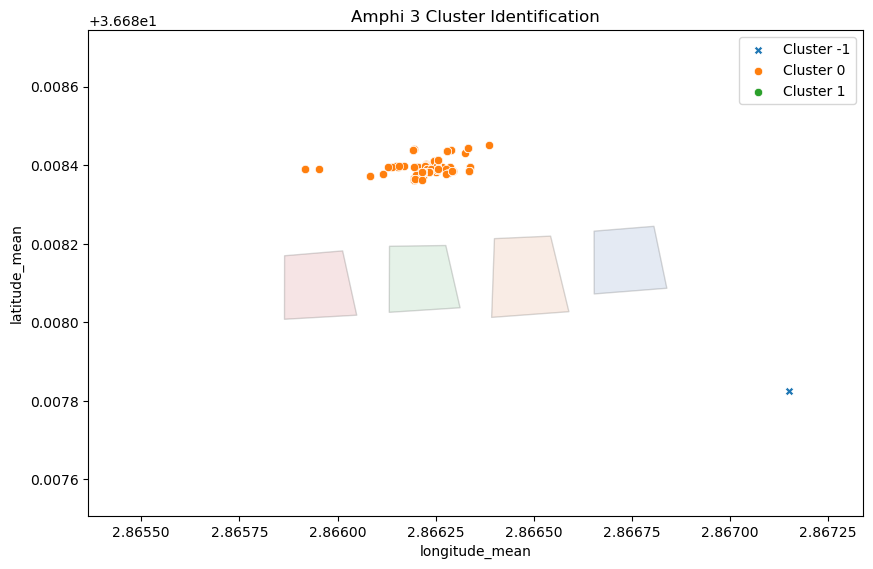

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', linewidth=1, zorder=1))

# Plot each cluster with a different color
clusters = sorted(df_a3['cluster'].unique())
for c in clusters:
    subset = df_a3[df_a3['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Set limits around the polygons
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 3 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [37]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 0 

df_a3_clean = df_a3[df_a3['cluster'] == SELECTED_CLUSTER].copy()
df_a3_noise = df_a3[df_a3['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_a3_clean)}")
print(f"Noise/outliers removed: {len(df_a3_noise)}")


Clean points kept: 296
Noise/outliers removed: 22


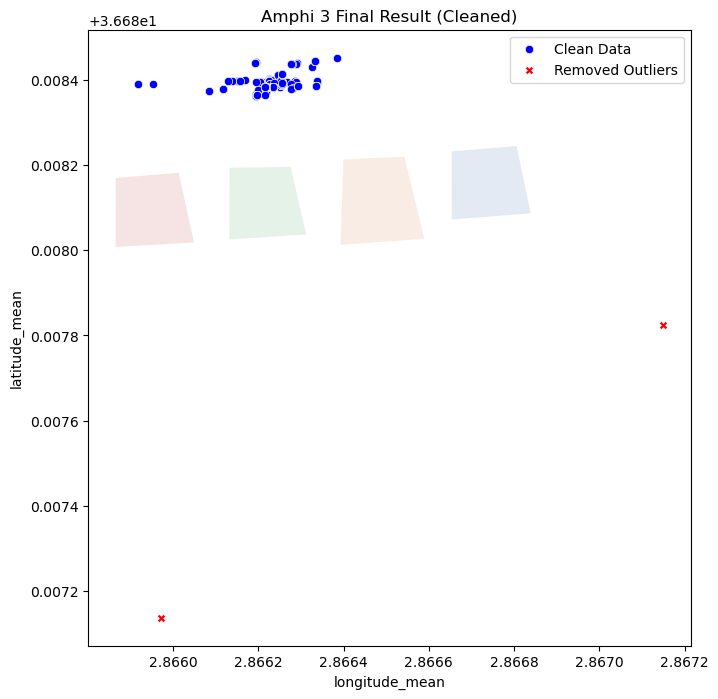

In [38]:
# Final validation plot for Amphi 3
fig, ax = plt.subplots(figsize=(10, 8))

# Draw polygons
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot clean data (Blue) and removed noise (Red X)
sns.scatterplot(data=df_a3_clean, x='longitude_mean', y='latitude_mean', color='blue', label='Clean Data', ax=ax, zorder=5)
sns.scatterplot(data=df_a3_noise, x='longitude_mean', y='latitude_mean', color='red', marker='X', label='Removed Outliers', ax=ax, zorder=4)

ax.set_title(f'Amphi 3 Final Result (Cleaned)')
ax.set_aspect('equal', adjustable='box')
plt.show()


# amphi 4 

In [39]:
# Build dataframe for Amphi 4 examples
df_a4 = df.loc[df['amphitheatre'] == 'Amphi 4', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a4['latitude_mean'] = pd.to_numeric(df_a4['latitude_mean'], errors='coerce')
df_a4['longitude_mean'] = pd.to_numeric(df_a4['longitude_mean'], errors='coerce')
df_a4 = df_a4.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 4 examples: {len(df_a4)}")
df_a4.head()


Amphi 4 examples: 741


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
3,5,Amphi 4,36.688630,2.866750,False
6461,6454,Amphi 4,36.688386,2.866126,False
6462,6455,Amphi 4,36.688386,2.866126,False
6463,6456,Amphi 4,36.688397,2.866160,False
6464,6457,Amphi 4,36.688395,2.866090,False


In [40]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a4 = df_a4[['latitude_mean', 'longitude_mean']].values

# Applying DBSCAN
db_a4 = DBSCAN(eps=0.00025, min_samples=15)
df_a4['cluster'] = db_a4.fit_predict(X_a4)

# Print cluster counts
print("Points per cluster for Amphi 4:")
print(df_a4['cluster'].value_counts().sort_index())


Points per cluster for Amphi 4:
cluster
-1      1
 0    740
Name: count, dtype: int64


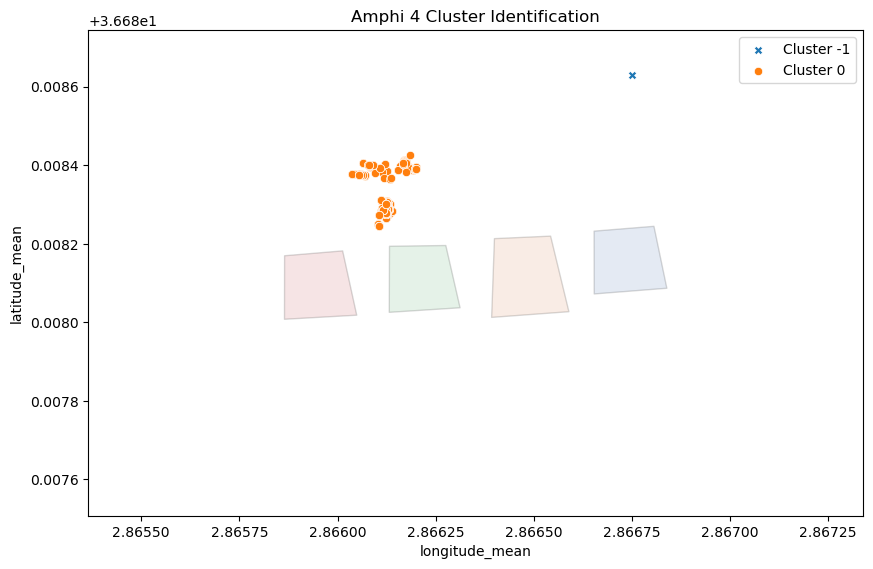

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', zorder=1))

# Plot each cluster
clusters = sorted(df_a4['cluster'].unique())
for c in clusters:
    subset = df_a4[df_a4['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Adjust view
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 4 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [42]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 0 

df_a4_clean = df_a4[df_a4['cluster'] == SELECTED_CLUSTER].copy()
df_a4_noise = df_a4[df_a4['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_a4_clean)}")
print(f"Noise/outliers removed: {len(df_a4_noise)}")


Clean points kept: 740
Noise/outliers removed: 1


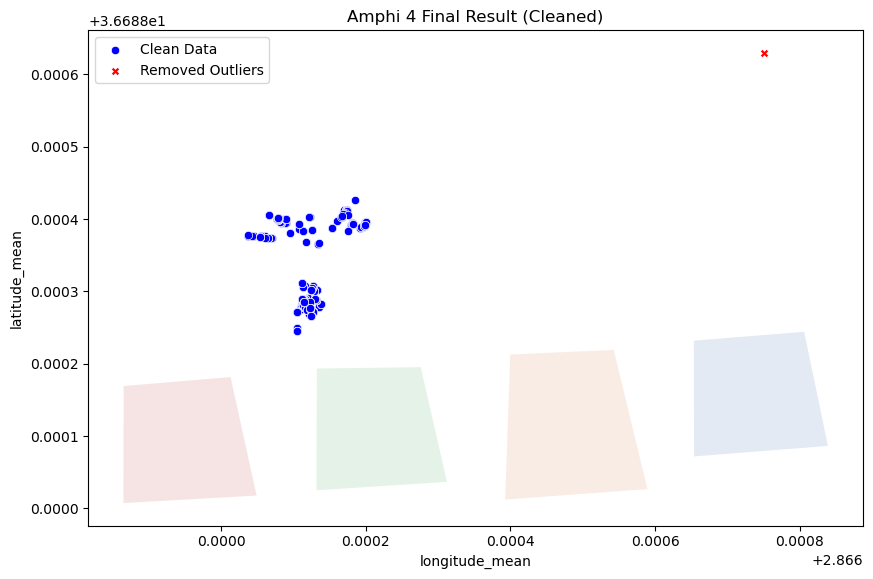

In [43]:
# Final validation plot for Amphi 4
fig, ax = plt.subplots(figsize=(10, 8))

# Draw polygons
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot clean data (Blue) and removed noise (Red X)
sns.scatterplot(data=df_a4_clean, x='longitude_mean', y='latitude_mean', color='blue', label='Clean Data', ax=ax, zorder=5)
sns.scatterplot(data=df_a4_noise, x='longitude_mean', y='latitude_mean', color='red', marker='X', label='Removed Outliers', ax=ax, zorder=4)

ax.set_title(f'Amphi 4 Final Result (Cleaned)')
ax.set_aspect('equal', adjustable='box')
plt.show()


# amphi 1 

In [44]:
# Build dataframe for Amphi 1 examples
df_a1 = df.loc[df['amphitheatre'] == 'Amphi 1', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a1['latitude_mean'] = pd.to_numeric(df_a1['latitude_mean'], errors='coerce')
df_a1['longitude_mean'] = pd.to_numeric(df_a1['longitude_mean'], errors='coerce')
df_a1 = df_a1.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 1 examples: {len(df_a1)}")
df_a1.head()


Amphi 1 examples: 625


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
12,12,Amphi 1,36.689937,2.861607,False
13,13,Amphi 1,36.689937,2.861607,False
17,14,Amphi 1,36.689937,2.861607,False
57,30,Amphi 1,36.688238,2.866921,False
78,47,Amphi 1,36.688371,2.866733,False


In [63]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a1 = df_a1[['latitude_mean', 'longitude_mean']].values

# Applying DBSCAN
db_a1 = DBSCAN(eps=0.000055, min_samples=25)
df_a1['cluster'] = db_a1.fit_predict(X_a1)

# Print cluster counts
print("Points per cluster for Amphi 1:")
print(df_a1['cluster'].value_counts().sort_index())


Points per cluster for Amphi 1:
cluster
-1     91
 0    456
 1     78
Name: count, dtype: int64


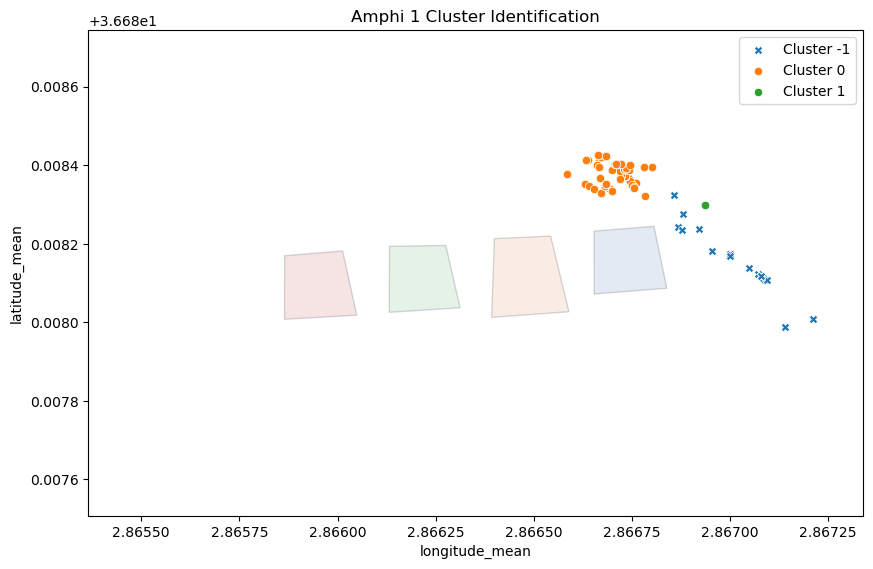

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', zorder=1))

# Plot each cluster
clusters = sorted(df_a1['cluster'].unique())
for c in clusters:
    subset = df_a1[df_a1['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Adjust view
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 1 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [65]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 0 

df_a1_clean = df_a1[df_a1['cluster'] == SELECTED_CLUSTER].copy()
df_a1_noise = df_a1[df_a1['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_a1_clean)}")
print(f"Noise/outliers removed: {len(df_a1_noise)}")


Clean points kept: 456
Noise/outliers removed: 169


# amphi 5 

In [66]:
# Build dataframe for Amphi 5 examples
df_a5 = df.loc[df['amphitheatre'] == 'Amphi 5', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a5['latitude_mean'] = pd.to_numeric(df_a5['latitude_mean'], errors='coerce')
df_a5['longitude_mean'] = pd.to_numeric(df_a5['longitude_mean'], errors='coerce')
df_a5 = df_a5.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 5 examples: {len(df_a5)}")
df_a5.head()


Amphi 5 examples: 1359


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
11,11,Amphi 5,36.753994,3.433505,False
21,18,Amphi 5,36.688390,2.866721,False
22,19,Amphi 5,36.688390,2.866721,False
24,20,Amphi 5,36.688390,2.866721,False
25,21,Amphi 5,36.688390,2.866721,False


In [67]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a5 = df_a5[['latitude_mean', 'longitude_mean']].values

# Applying DBSCAN with tuned parameters for Amphi 5
db_a5 = DBSCAN(eps=0.00008, min_samples=8)
df_a5['cluster'] = db_a5.fit_predict(X_a5)

# Print cluster counts
print("Points per cluster for Amphi 5:")
print(df_a5['cluster'].value_counts().sort_index())


Points per cluster for Amphi 5:
cluster
-1       9
 0    1270
 1      44
 2      10
 3      26
Name: count, dtype: int64


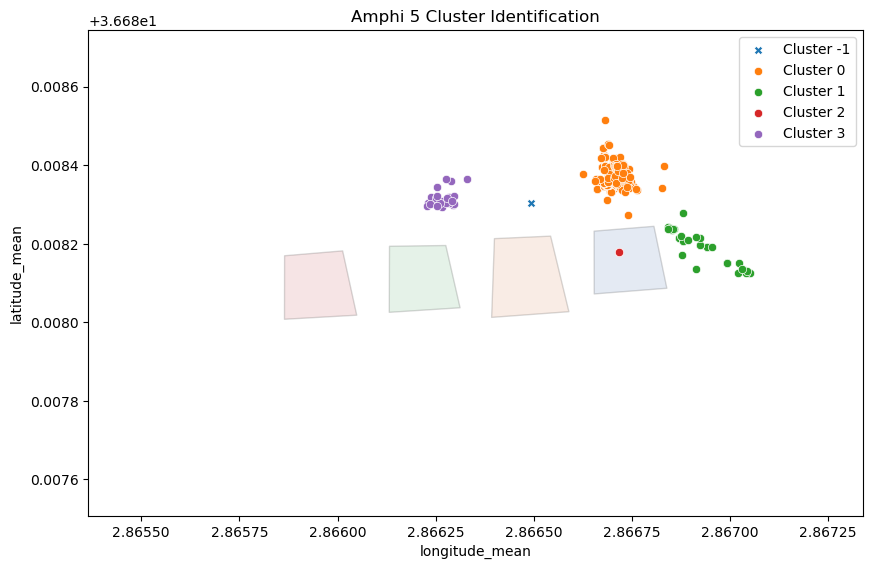

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', zorder=1))

# Plot each cluster
clusters = sorted(df_a5['cluster'].unique())
for c in clusters:
    subset = df_a5[df_a5['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Adjust view
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 5 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [69]:
# Select both Cluster 0 and Cluster 1 as clean data
SELECTED_CLUSTERS = [0, 1] 

# Filter for the selected clusters
df_a5_clean = df_a5[df_a5['cluster'].isin(SELECTED_CLUSTERS)].copy()
df_a5_noise = df_a5[~df_a5['cluster'].isin(SELECTED_CLUSTERS)].copy()

print(f"Clean points kept (Clusters 0 & 1): {len(df_a5_clean)}")
print(f"Noise/outliers removed: {len(df_a5_noise)}")


Clean points kept (Clusters 0 & 1): 1314
Noise/outliers removed: 45


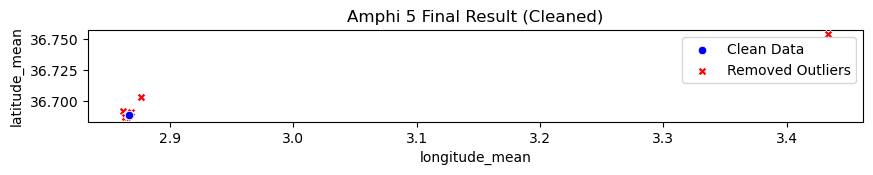

In [70]:
# Final validation plot for Amphi 5
fig, ax = plt.subplots(figsize=(10, 8))

# Draw polygons
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot clean data (Blue) and removed noise (Red X)
sns.scatterplot(data=df_a5_clean, x='longitude_mean', y='latitude_mean', color='blue', label='Clean Data', ax=ax, zorder=5)
sns.scatterplot(data=df_a5_noise, x='longitude_mean', y='latitude_mean', color='red', marker='X', label='Removed Outliers', ax=ax, zorder=4)

ax.set_title(f'Amphi 5 Final Result (Cleaned)')
ax.set_aspect('equal', adjustable='box')
plt.show()


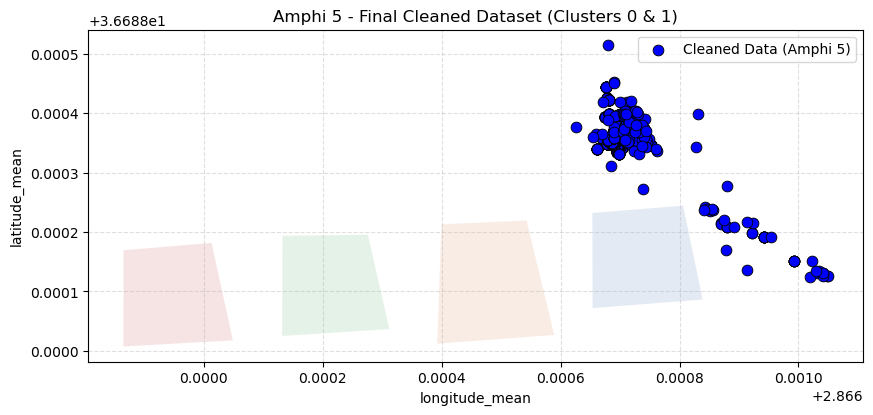

In [71]:
# Final validation plot for Amphi 5 - Cleaned Only
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons for context
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot ONLY the clean data (Clusters 0 and 1 combined)
sns.scatterplot(
    data=df_a5_clean, 
    x='longitude_mean', 
    y='latitude_mean', 
    color='blue', 
    s=60,
    edgecolor='black',
    label='Cleaned Data (Amphi 5)', 
    ax=ax, 
    zorder=5
)

ax.set_title('Amphi 5 - Final Cleaned Dataset (Clusters 0 & 1)')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.show()


# amphi 6 

In [72]:
# Build dataframe for Amphi 6 examples
df_a6 = df.loc[df['amphitheatre'] == 'Amphi 6', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a6['latitude_mean'] = pd.to_numeric(df_a6['latitude_mean'], errors='coerce')
df_a6['longitude_mean'] = pd.to_numeric(df_a6['longitude_mean'], errors='coerce')
df_a6 = df_a6.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 6 examples: {len(df_a6)}")
df_a6.head()


Amphi 6 examples: 936


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
26,22,Amphi 6,36.688317,2.866391,False
27,23,Amphi 6,36.688317,2.866391,False
28,25,Amphi 6,36.688317,2.866391,False
29,26,Amphi 6,36.688317,2.866391,False
32,24,Amphi 6,36.688317,2.866391,False


In [79]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a6 = df_a6[['latitude_mean', 'longitude_mean']].values

# Applying DBSCAN
db_a6 = DBSCAN(eps=0.00005, min_samples=15)
df_a6['cluster'] = db_a6.fit_predict(X_a6)

# Print cluster counts
print("Points per cluster for Amphi 6:")
print(df_a6['cluster'].value_counts().sort_index())


Points per cluster for Amphi 6:
cluster
-1     41
 0    895
Name: count, dtype: int64


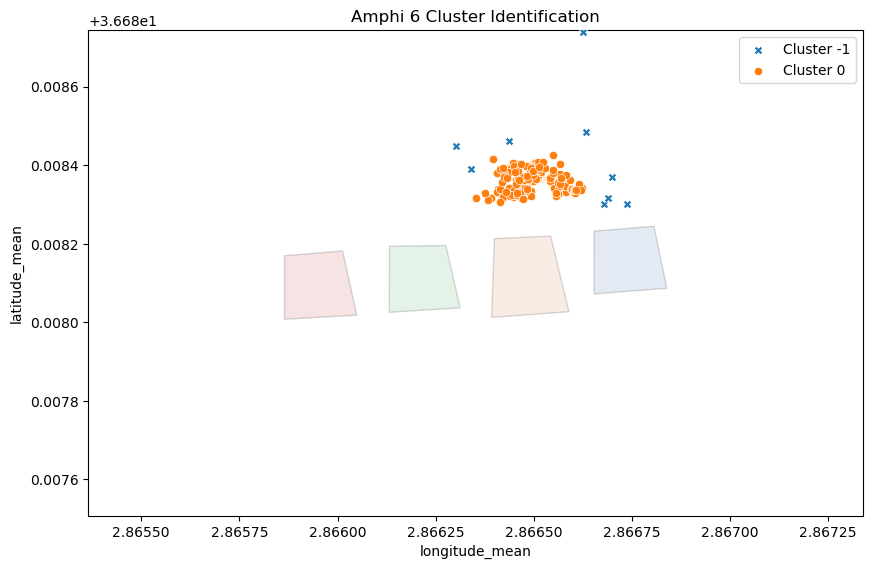

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', zorder=1))

# Plot each cluster
clusters = sorted(df_a6['cluster'].unique())
for c in clusters:
    subset = df_a6[df_a6['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Adjust view
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 6 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [81]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 0 

df_a6_clean = df_a6[df_a6['cluster'] == SELECTED_CLUSTER].copy()
df_a6_noise = df_a6[df_a6['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_a6_clean)}")
print(f"Noise/outliers removed: {len(df_a6_noise)}")


Clean points kept: 895
Noise/outliers removed: 41


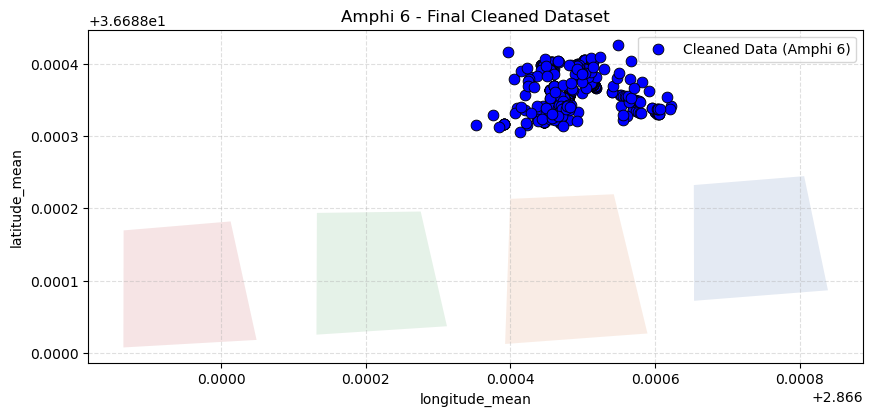

In [82]:
# Final validation plot for Amphi 6 - Cleaned Only
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons for context
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot ONLY the clean data
sns.scatterplot(
    data=df_a6_clean, 
    x='longitude_mean', 
    y='latitude_mean', 
    color='blue', 
    s=60,
    edgecolor='black',
    label='Cleaned Data (Amphi 6)', 
    ax=ax, 
    zorder=5
)

ax.set_title('Amphi 6 - Final Cleaned Dataset')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.show()


# amphi 7 

In [83]:
# Build dataframe for Amphi 7 examples
df_a7 = df.loc[df['amphitheatre'] == 'Amphi 7', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a7['latitude_mean'] = pd.to_numeric(df_a7['latitude_mean'], errors='coerce')
df_a7['longitude_mean'] = pd.to_numeric(df_a7['longitude_mean'], errors='coerce')
df_a7 = df_a7.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 7 examples: {len(df_a7)}")
df_a7.head()


Amphi 7 examples: 122


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
18,15,Amphi 7,36.685826,2.865137,False
58,31,Amphi 7,36.688304,2.866232,False
59,32,Amphi 7,36.688306,2.866236,False
61,33,Amphi 7,36.688306,2.866238,False
62,34,Amphi 7,36.688307,2.866239,False


In [84]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a7 = df_a7[['latitude_mean', 'longitude_mean']].values

# Applying DBSCAN
db_a7 = DBSCAN(eps=0.00025, min_samples=15)
df_a7['cluster'] = db_a7.fit_predict(X_a7)

# Print cluster counts
print("Points per cluster for Amphi 7:")
print(df_a7['cluster'].value_counts().sort_index())


Points per cluster for Amphi 7:
cluster
-1     11
 0    111
Name: count, dtype: int64


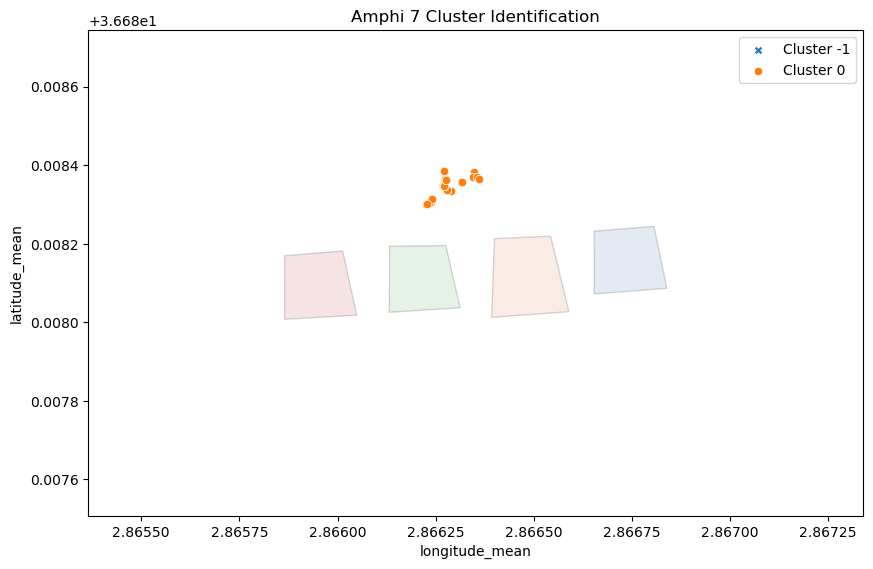

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    patches.append(Polygon(xy, closed=True))
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', zorder=1))

# Plot each cluster
clusters = sorted(df_a7['cluster'].unique())
for c in clusters:
    subset = df_a7[df_a7['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Adjust view
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 7 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [86]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 0 

df_a7_clean = df_a7[df_a7['cluster'] == SELECTED_CLUSTER].copy()
df_a7_noise = df_a7[df_a7['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_a7_clean)}")
print(f"Noise/outliers removed: {len(df_a7_noise)}")


Clean points kept: 111
Noise/outliers removed: 11


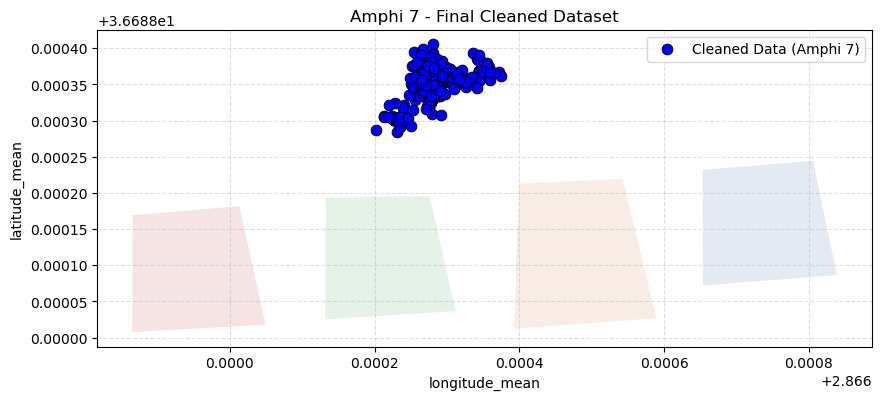

In [89]:
# Final validation plot for Amphi 7 - Cleaned Only
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons for context
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot ONLY the clean data
sns.scatterplot(
    data=df_a7_clean, 
    x='longitude_mean', 
    y='latitude_mean', 
    color='blue', 
    s=60,
    edgecolor='black',
    label='Cleaned Data (Amphi 7)', 
    ax=ax, 
    zorder=5
)

ax.set_title('Amphi 7 - Final Cleaned Dataset')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.show()


In [88]:
import numpy as np

# Target number of samples
TARGET_COUNT = 400
current_count = len(df_a7_clean)

if current_count < TARGET_COUNT:
    n_to_add = TARGET_COUNT - current_count
    print(f"Augmenting Amphi 7: Adding {n_to_add} synthetic examples to reach {TARGET_COUNT}...")

    # 1. Randomly sample existing points to use as a base for augmentation
    base_samples = df_a7_clean.sample(n_to_add, replace=True)

    # 2. Add small Gaussian noise (Jitter)
    # 0.00001 degrees is roughly 1 meter variation
    lat_noise = np.random.normal(0, 0.00001, n_to_add)
    lon_noise = np.random.normal(0, 0.00001, n_to_add)

    # Create the augmented data
    df_a7_augmented = base_samples.copy()
    df_a7_augmented['latitude_mean'] += lat_noise
    df_a7_augmented['longitude_mean'] += lon_noise
    
    # Change IDs to indicate they are synthetic (optional)
    df_a7_augmented['id'] = [f"aug_{i}" for i in range(n_to_add)]

    # 3. Combine original and augmented data
    df_a7_clean = pd.concat([df_a7_clean, df_a7_augmented], ignore_index=True)
    
    print(f"New total for Amphi 7: {len(df_a7_clean)}")
else:
    print(f"Amphi 7 already has {current_count} examples. No augmentation needed.")


Augmenting Amphi 7: Adding 289 synthetic examples to reach 400...
New total for Amphi 7: 400


# amphi 8 

In [90]:
# Build dataframe for Amphi 8 examples
df_a8 = df.loc[df['amphitheatre'] == 'Amphi 8', ['id', 'amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].copy()

# Ensure numeric types and drop NaNs
df_a8['latitude_mean'] = pd.to_numeric(df_a8['latitude_mean'], errors='coerce')
df_a8['longitude_mean'] = pd.to_numeric(df_a8['longitude_mean'], errors='coerce')
df_a8 = df_a8.dropna(subset=['latitude_mean', 'longitude_mean'])

print(f"Amphi 8 examples: {len(df_a8)}")
df_a8.head()


Amphi 8 examples: 989


,id,amphitheatre,latitude_mean,longitude_mean,is_outside
5752,7883,Amphi 8,36.688332,2.866137,False
5753,7884,Amphi 8,36.688332,2.866137,False
5754,7885,Amphi 8,36.688332,2.866137,False
5755,7886,Amphi 8,36.688332,2.866137,False
5756,7887,Amphi 8,36.688332,2.866137,False


In [97]:
from sklearn.cluster import DBSCAN

# Prepare coordinates for clustering
X_a8 = df_a8[['latitude_mean', 'longitude_mean']].values

# Applying DBSCAN
db_a8 = DBSCAN(eps=0.00010, min_samples=15)
df_a8['cluster'] = db_a8.fit_predict(X_a8)

# Print cluster counts
print("Points per cluster for Amphi 8:")
print(df_a8['cluster'].value_counts().sort_index())


Points per cluster for Amphi 8:
cluster
-1     30
 0    959
Name: count, dtype: int64


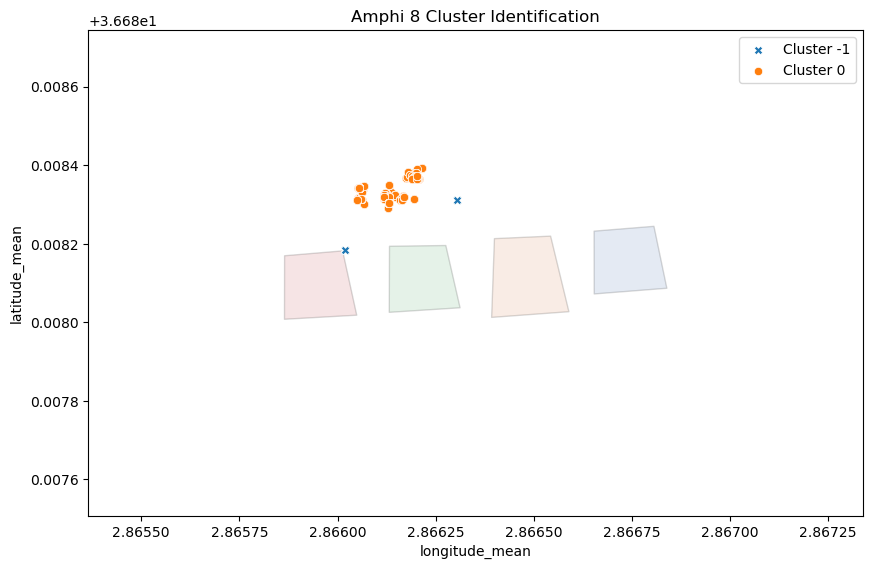

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Plot colored clusters against footprints
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons
patches = []
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C81']
for (_, corners), color in zip(amphi_corners.items(), colors):
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, edgecolor='black', zorder=1))

# Plot each cluster
clusters = sorted(df_a8['cluster'].unique())
for c in clusters:
    subset = df_a8[df_a8['cluster'] == c]
    sns.scatterplot(
        data=subset, x='longitude_mean', y='latitude_mean',
        marker='X' if c == -1 else 'o', label=f'Cluster {c}', ax=ax, zorder=5
    )

# Adjust view
poly_lats = [c[0] for corners in amphi_corners.values() for c in corners]
poly_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(poly_lons) - 0.0005, max(poly_lons) + 0.0005)
ax.set_ylim(min(poly_lats) - 0.0005, max(poly_lats) + 0.0005)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Amphi 8 Cluster Identification')
plt.legend(loc='best')
plt.show()


In [99]:
# UPDATE THE NUMBER BELOW based on Step 3 results
SELECTED_CLUSTER = 0 

df_a8_clean = df_a8[df_a8['cluster'] == SELECTED_CLUSTER].copy()
df_a8_noise = df_a8[df_a8['cluster'] != SELECTED_CLUSTER].copy()

print(f"Clean points kept: {len(df_a8_clean)}")
print(f"Noise/outliers removed: {len(df_a8_noise)}")


Clean points kept: 959
Noise/outliers removed: 30


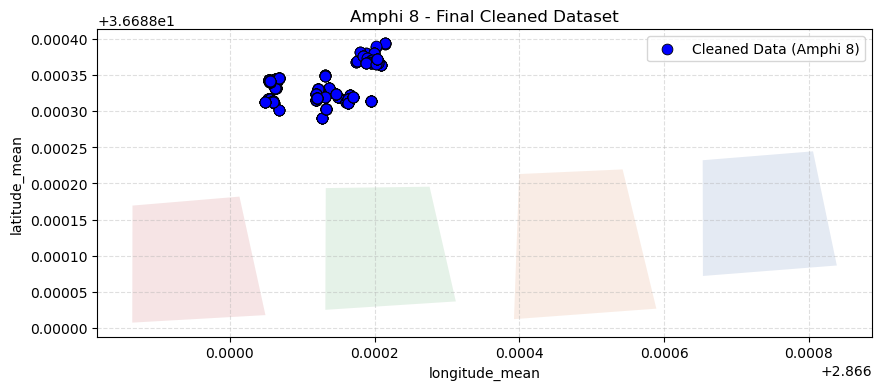

In [100]:
# Final validation plot for Amphi 8 - Cleaned Only
fig, ax = plt.subplots(figsize=(10, 8))

# Draw amphitheater polygons for context
patches = [Polygon(np.array([(lon, lat) for lat, lon in corners]), closed=True) for corners in amphi_corners.values()]
ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

# Plot ONLY the clean data
sns.scatterplot(
    data=df_a8_clean, 
    x='longitude_mean', 
    y='latitude_mean', 
    color='blue', 
    s=60,
    edgecolor='black',
    label='Cleaned Data (Amphi 8)', 
    ax=ax, 
    zorder=5
)

ax.set_title('Amphi 8 - Final Cleaned Dataset')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.show()


In [102]:
import pandas as pd
import os

# List of all cleaned dataframes
cleaned_dfs = [
    df_a1_clean, df_a2_clean, df_a3_clean, df_a4_clean, 
    df_a5_clean, df_a6_clean, df_a7_clean, df_a8_clean,
    df_outside_clean
]

# Concatenate all dataframes
df_final_cleaned = pd.concat(cleaned_dfs, ignore_index=True)

# Drop the 'cluster' column as it's no longer needed for training
if 'cluster' in df_final_cleaned.columns:
    df_final_cleaned = df_final_cleaned.drop(columns=['cluster'])

# Display final class distribution
print("Final Cleaned Dataset Distribution:")
print(df_final_cleaned['amphitheatre'].value_counts())

# Save to CSV
output_path = '../Data/ensia_gps_cleaned.csv'
df_final_cleaned.to_csv(output_path, index=False)

print(f"\nSuccessfully saved {len(df_final_cleaned)} examples to: {os.path.abspath(output_path)}")


Final Cleaned Dataset Distribution:
amphitheatre
Amphi 2    2417
Amphi 5    1314
Amphi 8     959
Amphi 6     895
Amphi 4     740
Outside     600
Amphi 1     456
Amphi 7     400
Amphi 3     296
Name: count, dtype: int64

Successfully saved 8077 examples to: c:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\ensia_gps_cleaned.csv
